# Uncertainty, explained like you're five: the **MI / BALD** decomposition

This notebook explains — very slowly and with pictures — how the NODE **flow head**
splits its uncertainty into two parts:

- **Data uncertainty** (aleatoric) — *the world is noisy.* Even a perfect model can't
  predict a coin flip.
- **Knowledge uncertainty** (epistemic) — *the model isn't sure.* It hasn't seen
  enough data. This one **shrinks** as you add more data.

By the end you'll understand the one formula that does the whole split:

$$
\underbrace{\text{total}}_{\text{entropy of the average}}
\;=\;
\underbrace{\text{data}}_{\text{average of the entropies}}
\;+\;
\underbrace{\text{knowledge}}_{\text{the gap}}
$$

That's it. The rest of this notebook is just making those three words obvious.

## 1. A picture of the two uncertainties

Imagine you ask: *"What will the temperature be tomorrow?"*

```
 ALEATORIC (data noise)              EPISTEMIC (model doesn't know)
 weather is just random              you asked a tourist, not a local

     probability                          probability
        |     .-.                            |   .-.        .-.
        |    /   \   <- one wide,            |  /   \      /   \   <- several
        |   /     \     fuzzy answer         | /     \    /     \     answers that
        |  /       \                         |/       \  /       \    DISAGREE
        +-------------- temp                 +--------------------- temp
        the model is confident               each guess is sharp, but
        the answer is 'blurry'               they point different ways
```

- **Aleatoric** = a *single* answer that is genuinely wide/blurry. More data won't fix it.
- **Epistemic** = *several* sharp answers that **disagree**. More data makes them agree.

The whole trick is: **how do we measure "disagreement" mathematically?**

## 2. Where the "several answers" come from: MC dropout

A neural net with **dropout** randomly switches off some neurons on every forward pass.
If we run the *same* input `x` through it `T` times, we get `T` slightly different
models — like asking `T` slightly different experts the same question.

```
                    ┌── dropout mask 1 ──►  expert 1 ──►  p₁(y|x)   (a whole curve!)
                    │
     x  ────────────┼── dropout mask 2 ──►  expert 2 ──►  p₂(y|x)
                    │
                    └── dropout mask T ──►  expert T ──►  pₜ(y|x)
```

**Key point:** each expert doesn't return a single number. Because this is a *flow* head,
each expert returns an **entire probability distribution** `p_t(y|x)` — a full curve over
possible `y` values.

## 3. "Entropy" = how wide is a curve

We need one number that says *"how spread out / uncertain is this curve?"* That number is
**entropy** $H$:

$$ H[p] \;=\; -\int p(y)\,\log p(y)\,dy \;=\; \mathbb{E}_{y\sim p}\big[-\log p(y)\big]. $$

You don't need the integral. Just remember the picture:

```
   narrow, confident            wide, uncertain
        .                           .-.
        |                         .'   '.
       .|.        LOW  H         /       \      HIGH H
      / | \                    .'         '.
   ---'--+--'---            ---'-----------'---
```

**Small entropy = sharp/confident. Big entropy = wide/uncertain.** That's all `H` means here.

## 3½. "But isn't entropy a *classification* thing?" — yes, and here's the bridge

Almost everyone (author included!) first meets entropy in **classification**, where it is a
**sum over a finite list of classes**:

$$ H_{\text{classif}} = -\sum_{k=1}^{K} p_k \,\log p_k \qquad(\text{cat / dog / bird, } K \text{ boxes}). $$

It measures *"how spread out am I over the boxes?"* — it is always $\ge 0$, is biggest for a
uniform guess, and is capped at $\log K$.

For **regression** there are no boxes — the answer $y$ is a real number on a continuous line.
So we do the only natural thing: **swap the sum for an integral** and the probabilities $p_k$
for a density $p(y)$:

$$ H_{\text{regr}}[p] = -\int p(y)\,\log p(y)\,dy . $$

This continuous version has its own name — **differential entropy** — but it is *literally the
same idea taken to the limit.* Here is the bridge, drawn:

```
  classification: a few tall bars          regression: chop the curve into
  over discrete classes                    tiny bins of width Δ  ->  bars again!

     p_k                                        p(y)
      |  █                                        |     .-.        each thin strip
      |  █   █                                    |   .'|||'.      is a "class" with
      |  █   █   █                                |  / |||||  \    probability p(y)·Δ
      +--+---+---+--- class                       +--||||||||||--- y
         cat dog bird                                (K -> ∞ bins)

     -Σ p_k log p_k                           -Σ (pΔ) log(pΔ)  =  -∫ p log p dy  -  log Δ
```

If you literally bin the continuous curve into strips of width $\Delta$ and plug it into the
**classification** formula, you get the regression integral **plus** a leftover $-\log\Delta$
term (the "how many bins did I use" bookkeeping). Differential entropy is just that limit with
the bin-count bookkeeping dropped. Same spirit — *"how wide / spread out is my belief?"* — only
now the belief lives on a continuous axis.

**Two honest differences from the classification version (don't panic when you see them):**

| | classification $H$ | differential $H$ (regression) |
|---|---|---|
| range | always $\ge 0$ | **can be negative** — a razor-sharp curve has *large negative* $H$ |
| units | bits/nats over classes | nats of *log-width*; depends on the units of $y$ |
| reads as | "how many classes am I unsure between" | "how wide is my curve" |

A **negative** data-uncertainty number is therefore **not a bug** — it just means the flow's
predicted curve for that point is narrower than one unit of $y$. It is still a perfectly valid
*ordering* of blurriness: less-negative = wider = more aleatoric noise.

**Why this is totally fine for BALD.** The two awkward bits above — the dropped $-\log\Delta$
resolution term and the "units of $y$" offset — are **identical** in `total` $=H[\bar p]$ and in
`data` $=\frac1T\sum_t H[p_t]$, because both are entropies of curves living on the *same* axis.
So when we take the gap

$$ \text{knowledge} = \text{total} - \text{data}, $$

**those offsets cancel exactly.** The epistemic (mutual-information) term comes out
resolution-independent, unit-independent, and provably $\ge 0$ — a genuine, well-behaved
"bits of disagreement" number — even though the individual differential entropies it is built
from are allowed to be negative. That is why we can happily use classification's entropy idea to
split regression uncertainty.

## 4. The one clever idea: two ways to "average"

We have `T` curves. There are **two different** ways to boil them down to a single width,
and the *difference* between them is the magic.

### Way A — **average the widths**  →  this is **DATA** (aleatoric)
Measure each expert's own width, then average the widths.
$$ \text{data} \;=\; \frac{1}{T}\sum_t H[p_t]. $$
"On average, how blurry is a single expert?"

### Way B — **width of the average**  →  this is **TOTAL**
First **stack all the curves and average them** into one pooled curve
$\bar p = \frac1T\sum_t p_t$, *then* measure that pooled curve's width.
$$ \text{total} \;=\; H\big[\bar p\big] \;=\; H\Big[\tfrac1T\textstyle\sum_t p_t\Big]. $$
"How blurry is the crowd's combined opinion?"

### The gap between them is **KNOWLEDGE** (epistemic)
$$ \boxed{\;\text{knowledge} \;=\; \text{total} - \text{data} \;=\; H[\bar p] - \tfrac1T\textstyle\sum_t H[p_t]\;} $$

This gap is called the **mutual information**, and the whole scheme is called **BALD**
(*Bayesian Active Learning by Disagreement*). It is **always ≥ 0**.

## 5. Why the gap = disagreement (the whole point)

### Case 1 — the experts AGREE
All `T` curves sit on top of each other.

```
   p₁ p₂ p₃  (all identical)          pooled average p̄
        .-.                                .-.
       /   \                              /   \
      /     \               ==>          /     \      SAME shape!
   --'-------'--                      --'-------'--

   width of average  ==  average of widths
   total             ==  data
   knowledge = total - data = 0     ✅ no disagreement, no epistemic uncertainty
```

### Case 2 — the experts DISAGREE
Each curve is sharp, but they point at different places.

```
   p₁      p₂      p₃                 pooled average p̄
   .-.     .-.     .-.                .-.   .-.   .-.
  /   \   /   \   /   \      ==>      /   \ /   \ /   \   WIDE & lumpy!
 -'---'-'---'-'---'---'-           -'---'-'---'-'---'--

   each expert is sharp   -> data (avg width) is SMALL
   the pooled crowd is wide -> total (width of avg) is BIG
   knowledge = total - data = BIG   ✅ lots of disagreement = high epistemic
```

> **That's the entire idea.** Epistemic uncertainty = *how much wider the crowd's pooled
> opinion is than a typical single opinion.* If everyone agrees, the crowd isn't any wider
> than one person, so knowledge = 0.

## 6. Let's actually compute it (tiny numeric demo)

No neural nets — just three little Gaussian "experts" so you can see the numbers.
We compute the widths (entropies) by simple numerical integration on a grid.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# NumPy renamed trapz -> trapezoid in 2.x; fall back for older versions
_integrate = getattr(np, "trapezoid", np.trapz)

# a grid of possible y values
y = np.linspace(-12, 12, 5000)


def gaussian(mu, sigma):
    """One expert's opinion: a bell curve over y."""
    return np.exp(-0.5 * ((y - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


def entropy(p):
    """How wide is this curve (differential entropy, via the grid)."""
    p = np.clip(p, 1e-12, None)
    return float(-_integrate(p * np.log(p), y))


def decompose(experts):
    """experts = list of (mu, sigma). Returns the BALD split."""
    curves = [gaussian(mu, s) for mu, s in experts]
    pooled = np.mean(curves, axis=0)  # p-bar = average of the curves
    data = np.mean([entropy(c) for c in curves])  # average of the widths
    total = entropy(pooled)  # width of the average
    knowledge = total - data  # the gap (mutual information)
    return curves, pooled, data, total, knowledge


print("Ready. Two scenarios coming up: experts that AGREE vs experts that DISAGREE.")

Ready. Two scenarios coming up: experts that AGREE vs experts that DISAGREE.


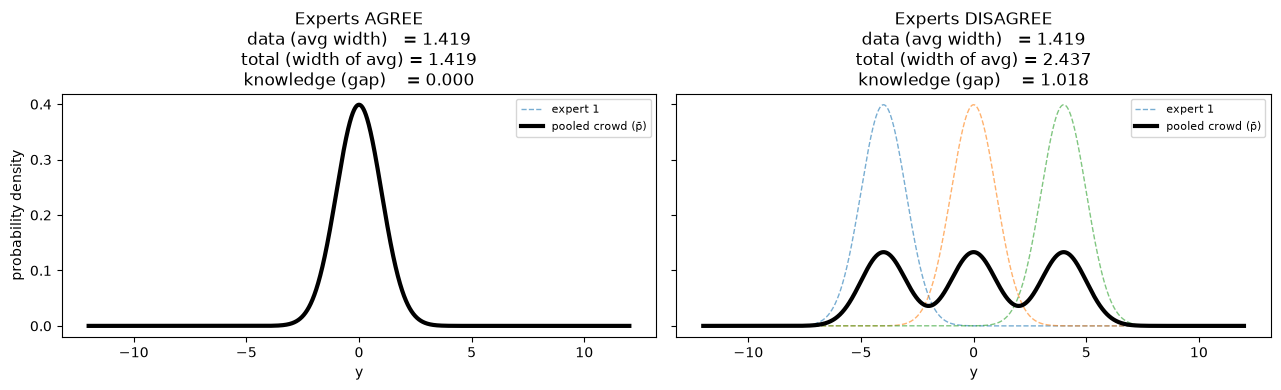

Notice: 'data' is almost identical in both (each expert is equally sharp).
Only 'knowledge' explodes when the experts disagree.


In [4]:
# Two scenarios, same individual sharpness (sigma=1), different agreement
agree = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]  # all point at 0
disagree = [(-4.0, 1.0), (0.0, 1.0), (4.0, 1.0)]  # point at -4, 0, +4

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, (title, experts) in zip(axes, [("Experts AGREE", agree), ("Experts DISAGREE", disagree)]):
    curves, pooled, data, total, knowledge = decompose(experts)
    for i, c in enumerate(curves):
        ax.plot(y, c, lw=1, ls="--", alpha=0.6, label=f"expert {i + 1}" if i == 0 else None)
    ax.plot(y, pooled, lw=3, color="black", label="pooled crowd (p\u0304)")
    ax.set_title(
        f"{title}\n"
        f"data (avg width)   = {data:.3f}\n"
        f"total (width of avg) = {total:.3f}\n"
        f"knowledge (gap)    = {knowledge:.3f}"
    )
    ax.set_xlabel("y")
    ax.legend(loc="upper right", fontsize=8)

axes[0].set_ylabel("probability density")
plt.tight_layout()
plt.show()

print("Notice: 'data' is almost identical in both (each expert is equally sharp).")
print("Only 'knowledge' explodes when the experts disagree.")

**What you just saw:**

| | experts AGREE | experts DISAGREE |
|---|---|---|
| each expert's width (`data`) | small | **same** small |
| pooled crowd width (`total`) | small | **big** |
| `knowledge = total − data` | ≈ 0 | **big** |

The aleatoric part (`data`) barely moved — each expert was equally sharp both times.
The epistemic part (`knowledge`) is *entirely* driven by the experts **disagreeing about
where `y` is**. That is exactly what we wanted.

## 7. How the code estimates the widths (Monte Carlo)

In the toy demo we integrated on a grid. Real flows live in many dimensions, so instead we
**draw samples** and average $-\log p$:

$$ H[p] \;=\; \mathbb{E}_{y\sim p}\big[-\log p(y)\big] \;\approx\; -\frac{1}{S}\sum_{s=1}^{S}\log p(y_s),\quad y_s\sim p. $$

So the flow's own `sample()` and `log_prob()` are all we need.

```
  for each expert p_t:
      draw S samples y_s ~ p_t          (ask the expert for example answers)
      width H[p_t] ≈ mean of -log p_t(y_s)
  data  = average of those widths
  total = same idea but scored under the POOLED p̄ (via log-sum-exp over experts)
  knowledge = total - data
```

## 7½. Monte-Carlo vs. grid quadrature — the *same* entropy, two ways to measure it

The BALSA paper computes the exact same continuous entropy, but with a **grid** instead of
sampling. Both are just numerical recipes for the one integral

$$ H[p] = -\int p(y)\,\log p(y)\,dy \;=\; \mathbb{E}_{y\sim p}\big[-\log p(y)\big]. $$

**Grid quadrature (the paper's `BALD_H`)** — lay down a *fixed, evenly-spaced* grid over the
target range (they normalise $y$ to $[0,1]$, ~200 nodes), read the density at every node, and
integrate with the trapezoidal rule:

$$ H[p] \approx -\sum_{g=1}^{G} p(y_g)\,\log p(y_g)\,\Delta . $$

**Monte-Carlo (what we do)** — *draw samples from the curve itself* and average $-\log p$:

$$ H[p] \approx -\frac1S\sum_{s=1}^{S}\log p(y_s), \qquad y_s \sim p . $$

```
   GRID: fixed ruler across the axis        MONTE-CARLO: ask the curve for examples
   (evaluate even where nothing lives)      (points land where the mass actually is)

     p(y)   |   |   |   |   |   |             p(y)          . ..:::.. .
       .-.  |   |  .:::.|   |   |               .-.           .:::::.
      /   \ |   |.:::::::.  |   |              /   \        ..:::::::::..
   --+--+--+--+--+--+--+--+--+--+--         --'-----'--   (samples ~ p, dense at the peak)
     wastes nodes in empty regions,          no wasted work; support handled for free
     can skip a spike between nodes
```

Same target number — they differ in **how the error behaves** and **how they scale**:

| | grid quadrature | Monte-Carlo (ours) |
|---|---|---|
| where evaluations land | fixed nodes, even in empty regions; may miss a spike *between* nodes | concentrate where $p$ is large (you sample from $p$) |
| dimension of $y$ | needs $G^{D}$ nodes → explodes for multi-target | cost is $S$ **regardless of $D$** |
| integration range | must pick bounds & truncate/renormalise | support handled automatically by the sampler |
| error type | deterministic **bias** from resolution $\Delta$ + truncation | **variance** (unbiased in expectation), shrinks like $1/\sqrt{S}$ |
| needs from the flow | `log_prob` on a grid | `log_prob` **and** `sample` |

**Why we picked Monte-Carlo:** the flow head must support **multi-target** regression, where a
grid of $G^{D}$ nodes is hopeless, and a normalizing flow hands us cheap exact `sample()` and
`log_prob()` — exactly MC's two ingredients. The only price is a little sampling noise, tamed by
raising $S$ (the number of flow samples per pass).

> **For the `total` term** the contrast is identical: the paper averages likelihood *vectors* on
> the grid into $\bar p$ then integrates; we sample $y$ from each expert and score it under the
> mixture $\bar p(y)=\frac1T\sum_{t'}p_{t'}(y)$ via `logsumexp` (the numerically-stable "log of an
> average of densities") before averaging $-\log\bar p$.

**Bottom line:** identical `BALD_H` decomposition — grid trades variance for a fixed
discretisation bias and stalls past 1-D; MC trades that bias for sampling variance and scales to
any target dimension.

## 8. Three things that confuse everyone (cleared up)

### Confusion 1: "Do we need lots of test points?"  → **No.**
There are **two different** kinds of "samples":

| name | what it is | how many |
|------|-----------|----------|
| `x` | the **input you predict on** | can be **just one** |
| `y_s` | **imaginary answers** the flow draws to measure its own width | many (internal only) |
| `p_t` | one **dropout expert** | `T` of them |

You can run the whole decomposition on a **single** `x`. The many `y_s` samples are drawn
*by the model itself* just to estimate the widths — they are **not** extra data you need.

### Confusion 2: "My data uncertainty is NEGATIVE — bug?"  → **No, that's fine.**
For continuous curves, `H` is a *differential* entropy, and it can be **negative** when a
curve is very tall and narrow (a probability **density** can be bigger than 1!).

```
        ||                a super-sharp, confident curve
        ||                peaks ABOVE 1  ->  log(density) > 0
        ||                ->  -log(density) < 0  ->  entropy can go NEGATIVE
   -----''-----
```

**A negative `data` value just means "very confident / very sharp".** It is a *relative*
score, not a magnitude that has to stay above zero. Only `knowledge` (the mutual
information) is guaranteed `≥ 0`.

### Confusion 3: "We used Gaussians above — so aren't we assuming a normal distribution?"  → **No.**
The toy demo used bell curves **only because they are easy to draw**. The real flow head is a
**normalizing flow**, which does *not* assume the answer is Gaussian. It learns an *invertible*
map $f_\theta$ that turns the target $y$ into a simple latent $z$ that *is* standard normal,
and reads off the density by change-of-variables:

$$
\log p(y\mid x) = \underbrace{\log \mathcal{N}\!\big(f_\theta(y\mid x)\big)}_{\text{normal in }z}
\;+\; \underbrace{\log\Big|\det \tfrac{\partial f_\theta}{\partial y}\Big|}_{\text{"stretch" (Jacobian)}} .
$$

The Gaussian lives **only in the hidden $z$-space**. The stretch term (the Jacobian) bends and
squashes that bell into whatever shape the data needs — skewed, heavy-tailed, or even
**multimodal** (several humps). That is the whole reason to use a flow instead of a plain
Gaussian head:

```
   latent z (always normal)        target y (any shape the data wants)
        .-.                             .-.        .-.
       /   \        f⁻¹ (bend        /   \      /   \     <- e.g. two humps
      /     \       & stretch)  ==> /     \    /     \       a Gaussian could
   --'-------'--                 --'-------'--'-------'--     never represent
```

Everything in this notebook — every width $H[p_t]$, the pooled width $H[\bar p]$, the whole
`total = data + knowledge` split — is computed purely from the flow's own **`sample()`** and
**`log_prob()`**. No step ever assumes $y$ is normal; the maths works for *any* shape the flow
learns. (The `data`/`total` numbers can still go negative for a very sharp flow — see
Confusion 2 — but that is about sharpness, not about being Gaussian.)


## 9. The cheat sheet

| Word | Formula | Plain English | Sign |
|------|---------|---------------|------|
| **data** (aleatoric) | $\frac1T\sum_t H[p_t]$ | average width of one expert | can be ± |
| **total** | $H[\frac1T\sum_t p_t]$ | width of the pooled crowd | can be ± |
| **knowledge** (epistemic) | $\text{total}-\text{data}$ | how much the experts disagree | **≥ 0** |

And the identity that always holds:

$$ \text{total} \;=\; \text{data} \;+\; \text{knowledge}. $$

**Rules of thumb**
- Big `data`  → the world is noisy here (more data won't help).
- Big `knowledge` → the model is guessing (get more data / it's out-of-distribution).
- `knowledge ≈ 0` → the dropout experts all agree; the model is confident.

## 10. Bonus: classification uses the *exact same* formula

For a classifier, each dropout expert outputs a **class-probability vector** $p_t$ instead
of a curve, and $H$ is the ordinary Shannon entropy $H(p) = -\sum_c p_c \log p_c$:

$$
\underbrace{H(\bar p)}_{\text{total}}
= \underbrace{\tfrac1T\textstyle\sum_t H(p_t)}_{\text{data}}
+ \underbrace{\big[H(\bar p) - \tfrac1T\textstyle\sum_t H(p_t)\big]}_{\text{knowledge}}
$$

Same three words, same picture (agree vs disagree), same `total = data + knowledge`. The
only difference is *curves* (flow / regression) vs *bars* (classes / classification). This
is the CatBoost / Malinin decomposition used elsewhere in Mother.

---
**In one sentence:** *epistemic uncertainty is how much wider the crowd's pooled opinion is
than a single opinion — and if the crowd agrees, that width is zero.*

## 11. Where next: **BALSA** — measuring disagreement *directly*

Everything above turned each expert's curve into **one number** (its width $H[p_t]$) and then
compared numbers. That works, but squashing a whole curve down to a single width **throws away
a lot of information** — *where* the curves sit, *how* they differ in shape, etc. In fact, for
normalizing flows people found that width-style scores (entropy, std, "least confident") often
pick **bad** points to label next in active learning.

**BALSA** (*Bayesian Active Learning by distribution disagreement*, Werner & Schmidt-Thieme,
2025) fixes this by comparing the **full curves against each other**, instead of comparing their
widths:

$$
\underbrace{\text{BALD}(x) = \sum_t \big(H[\bar p] - H[p_t]\big)}_{\text{compare \emph{widths} (what this notebook did)}}
\qquad\longrightarrow\qquad
\underbrace{\text{BALSA}(x) = \sum_t \phi\big(p_t,\; \bar p\big)}_{\text{compare the whole \emph{curves} with a distance } \phi}
$$

where $\phi$ is a proper **distribution distance** and $\bar p = \frac1T\sum_t p_t$ is the same
pooled "crowd" curve as before.

```
  BALD  view                         BALSA view
  ----------                         -----------
  p₁ -> width 1.2                    p₁ ─┐
  p₂ -> width 1.1                    p₂ ─┼─► how far apart are the CURVES?
  p₃ -> width 1.3                    p₃ ─┘     φ(p_t , crowd)   or   φ(p_t , p_{t+1})
      then compare numbers               (uses the whole shape, not one number)
```

**Two ways to pick the distance $\phi$:**

| variant | distance $\phi$ | how it's built | note |
|---|---|---|---|
| **BALSA-KL** | KL divergence | on a grid of the curves' likelihoods | `KL Pair` was **best overall** in the paper |
| **BALSA-EMD** | Earth-Mover / Wasserstein | on samples drawn from each curve | intuitive "cost to reshape one into the other" |

…and **two ways to form the "crowd"** you compare against:
- **Grid**: evaluate every $p_t$ on a fixed grid of $y$-values → average into $\bar p$ → compare each $p_t$ to $\bar p$.
- **Pair**: skip $\bar p$ entirely; just compare *consecutive experts* $\phi(p_t, p_{t+1})$ and sum — cheaper, and since the experts are i.i.d. the order doesn't matter.

> **One-liner:** BALD asks *"is the crowd's curve wider than one expert's?"*; BALSA asks the
> sharper question *"how differently shaped are the experts' curves from each other?"*

### How this would slot into Mother (not implemented yet)

The good news: the flow head's uncertainty routine **already builds every ingredient BALSA
needs** — no re-training, barely any new compute:

- We already run `T` MC-dropout passes and keep each expert's flow $p_t$ plus samples from it.
- We already cross-score every sample under every expert (`log p_{t'}(y_{t,s})`) to get the
  pooled width `total`. **`BALSA-KL Pair` falls straight out of that same tensor**, because
  $\;\mathrm{KL}(p_t, p_{t+1}) \approx \frac1S\sum_s\big[\log p_t(y_s) - \log p_{t+1}(y_s)\big],\; y_s\sim p_t$ — essentially free.
- `BALSA-KL Grid` just needs a fixed 1-D grid + `flow.log_prob` on it; `BALSA-EMD` needs a 1-D
  Wasserstein distance on the samples we already draw.

A natural API would be a sibling method such as
`acquisition_score(X, method="balsa_kl_pair" | "balsa_kl_grid" | "balsa_emd" | "bald")`
that reuses the exact MC-dropout loop from this notebook and only swaps the **final reduction** —
the `knowledge` (BALD) score we built here becomes the `"bald"` baseline. It is aimed at
**active learning** (picking the most informative next point to label), and the paper recommends
a **low** dropout rate (~0.05) rather than the classic 0.5.

*Reference:* Werner & Schmidt-Thieme, *Bayesian Active Learning by Distribution Disagreement*,
arXiv:2501.01248 (2025).